# Fahrererkennung mit k-Means Clustering
**ISKI Projekt Gruppe 2** · Kuhn-Munkres Hungarian Matching · n_init=1000

In [263]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.optimize import linear_sum_assignment
from scipy.spatial import ConvexHull
from collections import Counter

CSV_PATH = 'driver_features_combined.csv'
df_raw = pd.read_csv(CSV_PATH)
df_raw['driver_id'] = df_raw['driver_id'].str.strip('_')

print(f'Datensatz: {df_raw.shape[0]} Zeilen | {df_raw["driver_id"].nunique()} Fahrer')
print(f'Fahrer: {sorted(df_raw["driver_id"].unique())}')


Datensatz: 2472 Zeilen | 25 Fahrer
Fahrer: ['ALAD201', 'ANIC011', 'BRIG160', 'CHKA302', 'FARC062', 'FEFH030', 'FIND031', 'ISMS130', 'JADR090', 'JOI033', 'JORC051', 'KEPD180', 'KETZ160', 'LIAZ070', 'MAKR091', 'MIBE102', 'NIDL241', 'NIMB230', 'OLOT290', 'RINE150', 'SEMD260', 'SHMM240', 'SOMD122', 'THTH312', 'TOMS241']


In [264]:
FEATURE_COLS = [
    'steering_smoothness', 'steering_rate_mean', 'throttle_aggressive',
    'throttle_smoothness', 'trail_brake_pct', 'jerk_mean', 'g_lat_std', 'g_long_std',
]
OUTLIER_COLS = ['percent_brake_std', 'percent_throttle_std', 'v_car_std']
RANDOM_SEED  = 42
DRIVERS_5    = ['ALAD201', 'NIMB230', 'SOMD122', 'THTH312', 'RINE150']

# Schritt 1: Segment-Bereinigung (IQR x 1.5) pro Fahrer
cleaned = []
for driver, grp in df_raw.groupby('driver_id'):
    g = grp.copy()
    for col in OUTLIER_COLS:
        if col not in g.columns: continue
        Q1, Q3 = g[col].quantile(0.25), g[col].quantile(0.75)
        IQR = Q3 - Q1
        g = g[(g[col] >= Q1 - 1.5*IQR) & (g[col] <= Q3 + 1.5*IQR)]
    cleaned.append(g)
df_clean = pd.concat(cleaned, ignore_index=True)
print(f'Nach Bereinigung: {len(df_clean)} Segmente ({df_raw.shape[0]-len(df_clean)} entfernt)')

# Schritt 2: Per-Fahrer Feature-Clipping (IQR x 1.5)
df_feat = df_clean.copy()
for col in FEATURE_COLS:
    df_feat[col] = df_feat[col].astype(float)
for driver, grp in df_feat.groupby('driver_id'):
    for col in FEATURE_COLS:
        Q1, Q3 = grp[col].quantile(0.25), grp[col].quantile(0.75)
        IQR = Q3 - Q1
        if IQR == 0: continue
        df_feat.loc[grp.index, col] = grp[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
print(f'Clipping abgeschlossen. Datenbasis: {len(df_feat)} Segmente')


Nach Bereinigung: 2275 Segmente (197 entfernt)
Clipping abgeschlossen. Datenbasis: 2275 Segmente


In [265]:
def kmeans(X, k, n_init=1000, max_iter=300, seed=42):
    rng = np.random.default_rng(seed)
    best_inertia, best_labels, best_centers = np.inf, None, None
    X_sq = (X**2).sum(axis=1)
    for _ in range(n_init):
        centers = X[rng.choice(len(X), k, replace=False)].copy()
        labels  = np.zeros(len(X), dtype=int)
        for _ in range(max_iter):
            C_sq  = (centers**2).sum(axis=1)
            new_l = (X_sq[:,None] - 2*(X @ centers.T) + C_sq[None,:]).argmin(axis=1)
            if np.all(new_l == labels): break
            labels = new_l
            for j in range(k):
                pts = X[labels == j]
                if len(pts): centers[j] = pts.mean(axis=0)
        C_sq    = (centers**2).sum(axis=1)
        inertia = (X_sq[:,None] - 2*(X @ centers.T) + C_sq[None,:])[np.arange(len(X)), labels].sum()
        if inertia < best_inertia:
            best_inertia, best_labels, best_centers = inertia, labels.copy(), centers.copy()
    return best_labels, best_centers

def hungarian_mapping(contingency):
    row_ind, col_ind = linear_sum_assignment(-contingency)
    return {int(r): int(c) for r, c in zip(row_ind, col_ind)}

print('k-Means (n_init=1000) + Kuhn-Munkres Hungarian Mapping bereit.')


k-Means (n_init=1000) + Kuhn-Munkres Hungarian Mapping bereit.


In [266]:
drivers_all = sorted(df_feat['driver_id'].unique())
k25 = len(drivers_all)

train25, test25 = train_test_split(
    df_feat, test_size=0.2, random_state=RANDOM_SEED, stratify=df_feat['driver_id']
)
train25, test25 = train25.copy(), test25.copy()

sc25 = StandardScaler()
X_tr25 = sc25.fit_transform(train25[FEATURE_COLS])
X_te25 = sc25.transform(test25[FEATURE_COLS])

print(f'[25 Fahrer] Training: {len(train25)} | Test: {len(test25)}')
print('[25 Fahrer] k-Means laeuft (n_init=1000) ... (ca. 30-90 s)')
lbl25, ctr25 = kmeans(X_tr25, k25, n_init=1000, seed=RANDOM_SEED)
train25['Cluster_ID'] = lbl25
print('[25 Fahrer] Fertig!')

d2i25 = {d: i for i, d in enumerate(drivers_all)}
cont25 = np.zeros((k25, k25), dtype=int)
for cl, dr in zip(train25['Cluster_ID'], train25['driver_id']):
    cont25[cl, d2i25[dr]] += 1
map25 = hungarian_mapping(cont25)
c2d25 = {cl: drivers_all[dr_i] for cl, dr_i in map25.items()}

X_sq  = (X_te25**2).sum(1); C_sq = (ctr25**2).sum(1)
tl25  = (X_sq[:,None] - 2*(X_te25@ctr25.T) + C_sq[None,:]).argmin(1)
yp25  = [c2d25.get(l,'?') for l in tl25]
test25['Erkannter_Fahrer'] = yp25
agr25 = accuracy_score(test25['driver_id'], yp25)
print(f'[25 Fahrer] Agreement (Segment-Level): {agr25:.1%}')

# Majority Vote (je 12 Segmente)
y_true25 = test25['driver_id'].values
y_pred25 = np.array(yp25)
runden25 = []
for i in range(0, len(y_true25), 12):
    yt = y_true25[i:i+12]; yp = y_pred25[i:i+12]
    if len(yt)==0: continue
    runden25.append((Counter(yt).most_common(1)[0][0], Counter(yp).most_common(1)[0][0]))
mv25 = float(np.mean([t==p for t,p in runden25]))
print(f'[25 Fahrer] Majority Vote: {mv25:.1%}')


[25 Fahrer] Training: 1820 | Test: 455
[25 Fahrer] k-Means laeuft (n_init=1000) ... (ca. 30-90 s)
[25 Fahrer] Fertig!
[25 Fahrer] Agreement (Segment-Level): 24.8%
[25 Fahrer] Majority Vote: 7.9%


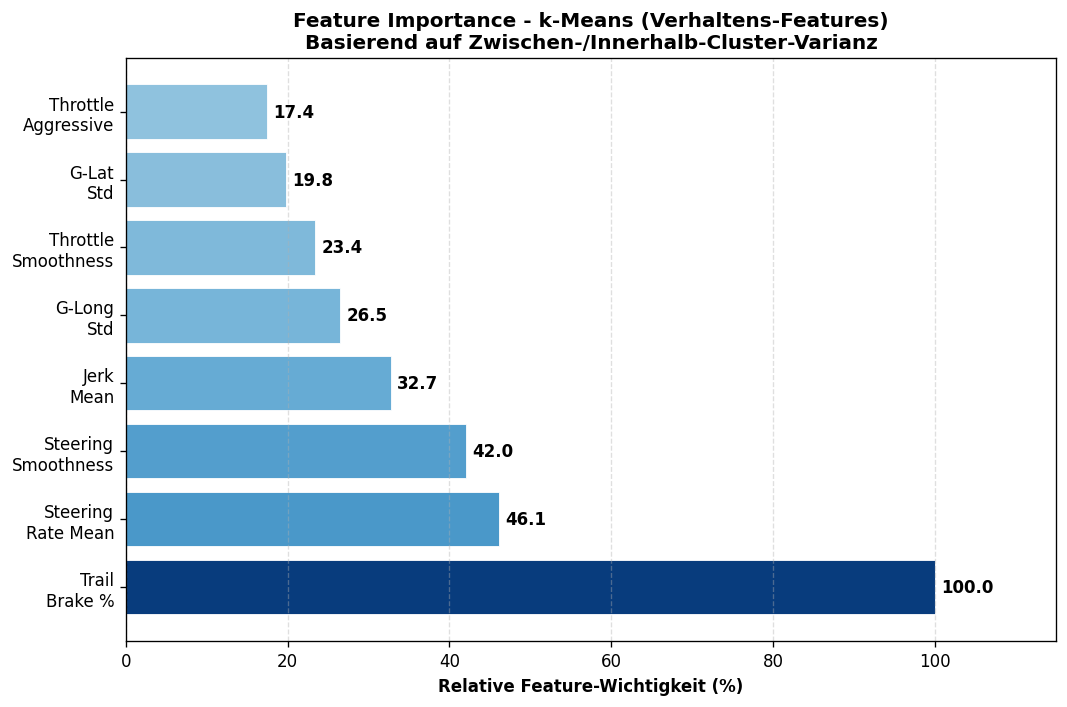

In [267]:
global_mean = X_tr25.mean(axis=0)
between_var = np.zeros(X_tr25.shape[1])
within_var  = np.zeros(X_tr25.shape[1])
for j in range(k25):
    pts = X_tr25[lbl25 == j]
    if len(pts) == 0: continue
    cm_j = pts.mean(axis=0)
    between_var += len(pts) * (cm_j - global_mean)**2
    within_var  += ((pts - cm_j)**2).sum(axis=0)
importance     = between_var / (within_var + 1e-9)
importance_rel = 100 * importance / importance.max()

order      = np.argsort(importance_rel)[::-1]  # gross -> klein (gross unten bei barh)
feat_names = np.array(FEATURE_COLS)[order]
feat_vals  = importance_rel[order]

label_map = {
    'steering_smoothness': 'Steering\nSmoothness', 'steering_rate_mean': 'Steering\nRate Mean',
    'throttle_aggressive': 'Throttle\nAggressive', 'throttle_smoothness': 'Throttle\nSmoothness',
    'trail_brake_pct': 'Trail\nBrake %', 'jerk_mean': 'Jerk\nMean',
    'g_lat_std': 'G-Lat\nStd', 'g_long_std': 'G-Long\nStd',
}
norm_colors = feat_vals / feat_vals.max()
colors_fi   = [plt.cm.Blues(0.3 + 0.65 * v) for v in norm_colors]

fig, ax = plt.subplots(figsize=(9, 6), dpi=120)
bars = ax.barh([label_map.get(f,f) for f in feat_names], feat_vals,
               color=colors_fi, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, feat_vals):
    ax.text(val+0.8, bar.get_y()+bar.get_height()/2, f'{val:.1f}',
            va='center', fontweight='bold', fontsize=10)
ax.set_xlim(0, 115)
ax.set_xlabel('Relative Feature-Wichtigkeit (%)', fontweight='bold')
ax.set_title('Feature Importance - k-Means (Verhaltens-Features)\n'
             'Basierend auf Zwischen-/Innerhalb-Cluster-Varianz', fontweight='bold', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [268]:
df5 = df_feat[df_feat['driver_id'].isin(DRIVERS_5)].copy()
print(f'5-Fahrer: {sorted(df5["driver_id"].unique())} | {len(df5)} Segmente')

train5, test5 = train_test_split(
    df5, test_size=0.2, random_state=RANDOM_SEED, stratify=df5['driver_id']
)
train5, test5 = train5.copy(), test5.copy()

sc5 = StandardScaler()
X_tr5 = sc5.fit_transform(train5[FEATURE_COLS])
X_te5 = sc5.transform(test5[FEATURE_COLS])

print(f'[5 Fahrer] Training: {len(train5)} | Test: {len(test5)}')
print('[5 Fahrer] k-Means laeuft (n_init=1000) ...')
lbl5, ctr5 = kmeans(X_tr5, 5, n_init=1000, seed=RANDOM_SEED)
train5['Cluster_ID'] = lbl5
print('[5 Fahrer] Fertig!')

d2i5  = {d: i for i, d in enumerate(DRIVERS_5)}
cont5 = np.zeros((5,5), dtype=int)
for cl, dr in zip(train5['Cluster_ID'], train5['driver_id']):
    cont5[cl, d2i5[dr]] += 1
map5 = hungarian_mapping(cont5)
c2d5 = {cl: DRIVERS_5[dr_i] for cl, dr_i in map5.items()}

X_sq5 = (X_te5**2).sum(1); C_sq5 = (ctr5**2).sum(1)
tl5   = (X_sq5[:,None] - 2*(X_te5@ctr5.T) + C_sq5[None,:]).argmin(1)
yp5   = [c2d5.get(l,'?') for l in tl5]
test5['Erkannter_Fahrer'] = yp5
agr5  = accuracy_score(test5['driver_id'], yp5)
print(f'[5 Fahrer] Agreement (Segment-Level): {agr5:.1%}')

# Majority Vote
y_true5 = test5['driver_id'].values
y_pred5 = np.array(yp5)
runden5 = []
for i in range(0, len(y_true5), 12):
    yt = y_true5[i:i+12]; yp = y_pred5[i:i+12]
    if len(yt)==0: continue
    runden5.append((Counter(yt).most_common(1)[0][0], Counter(yp).most_common(1)[0][0]))
mv5 = float(np.mean([t==p for t,p in runden5]))
print(f'[5 Fahrer] Majority Vote: {mv5:.1%}')


5-Fahrer: ['ALAD201', 'NIMB230', 'RINE150', 'SOMD122', 'THTH312'] | 469 Segmente
[5 Fahrer] Training: 375 | Test: 94
[5 Fahrer] k-Means laeuft (n_init=1000) ...
[5 Fahrer] Fertig!
[5 Fahrer] Agreement (Segment-Level): 59.6%
[5 Fahrer] Majority Vote: 50.0%


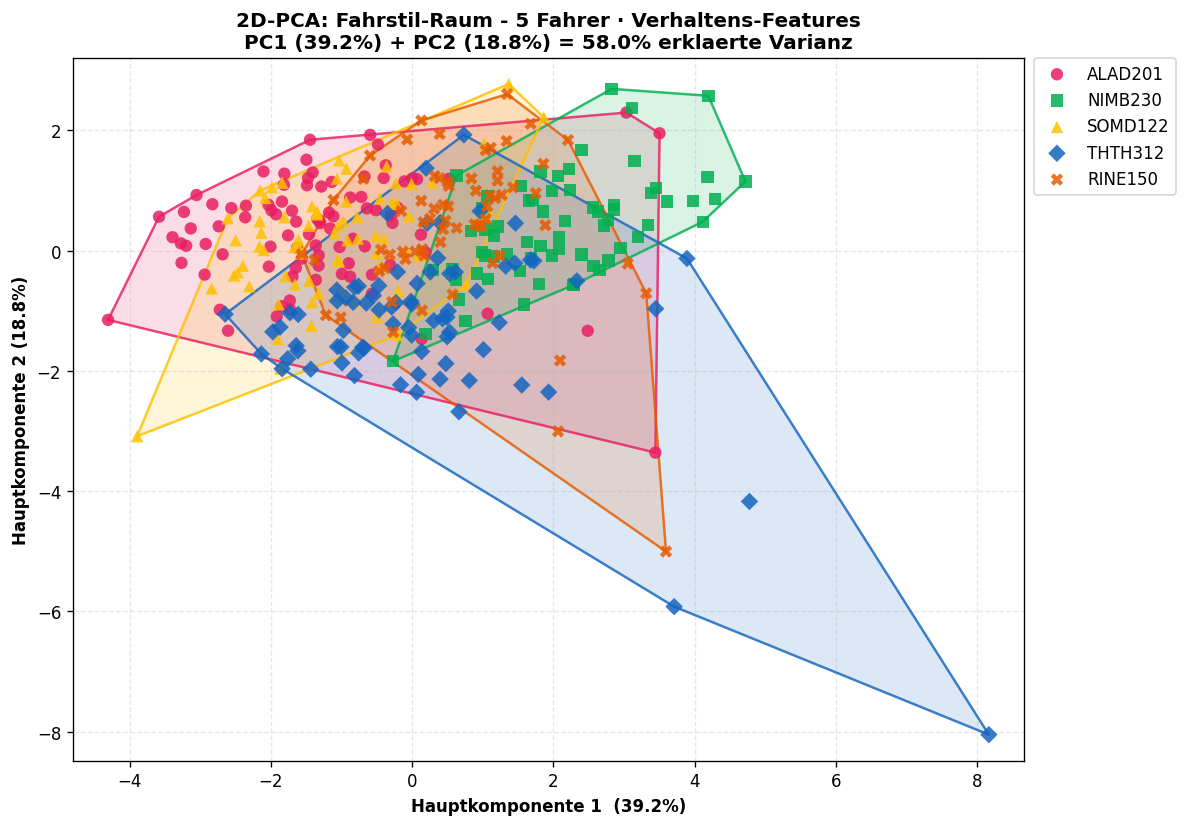

In [269]:
# 2D-PCA: 5 Fahrer (ohne per-Fahrer-Clipping fuer Visualisierung)
X_tr5_nc_vals = df_clean.loc[train5.index, FEATURE_COLS].values.astype(float)
mu_nc5  = X_tr5_nc_vals.mean(0)
sig_nc5 = X_tr5_nc_vals.std(0) + 1e-9
X_tr5_nc = (X_tr5_nc_vals - mu_nc5) / sig_nc5

_, S_5, Vt_5 = np.linalg.svd(X_tr5_nc, full_matrices=False)
var5 = (S_5[:2]**2) / (S_5**2).sum()
X_pca5      = X_tr5_nc @ Vt_5[:2].T
driver_ids5 = train5['driver_id'].values

d_colors5  = {
    'ALAD201': '#e91e63', 'NIMB230': '#00b050',
    'SOMD122': '#ffc000', 'THTH312': '#1565c0', 'RINE150': '#e65c00',
}
d_markers5 = {'ALAD201':'o','NIMB230':'s','SOMD122':'^','THTH312':'D','RINE150':'X'}

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
for driver in DRIVERS_5:
    mask = driver_ids5 == driver
    pts  = X_pca5[mask]
    col  = d_colors5[driver]; mrk = d_markers5[driver]
    ax.scatter(pts[:,0], pts[:,1], c=col, marker=mrk, s=55, alpha=0.85,
               label=driver, edgecolors='none', zorder=3)
    if len(pts) >= 3:
        try:
            hull = ConvexHull(pts)
            hp = pts[hull.vertices]; hp = np.vstack([hp, hp[0]])
            ax.fill(hp[:,0], hp[:,1], alpha=0.15, color=col, zorder=1)
            ax.plot(hp[:,0], hp[:,1], color=col, linewidth=1.5, alpha=0.8, zorder=2)
        except: pass

ax.set_title(
    f'2D-PCA: Fahrstil-Raum - 5 Fahrer · Verhaltens-Features\n'
    f'PC1 ({var5[0]*100:.1f}%) + PC2 ({var5[1]*100:.1f}%) = {var5[:2].sum()*100:.1f}% erklaerte Varianz',
    fontweight='bold', fontsize=12)
ax.set_xlabel(f'Hauptkomponente 1  ({var5[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'Hauptkomponente 2 ({var5[1]*100:.1f}%)', fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=True, fontsize=10, borderaxespad=0)
ax.grid(True, linestyle='--', alpha=0.3)
# Achsengrenzen eng an Datenpunkte
_ax, _ay = X_pca5[:,0], X_pca5[:,1]
_px, _py = (_ax.max()-_ax.min())*0.04, (_ay.max()-_ay.min())*0.04
ax.set_xlim(_ax.min()-_px, _ax.max()+_px)
ax.set_ylim(_ay.min()-_py, _ay.max()+_py)
plt.tight_layout()
plt.show()


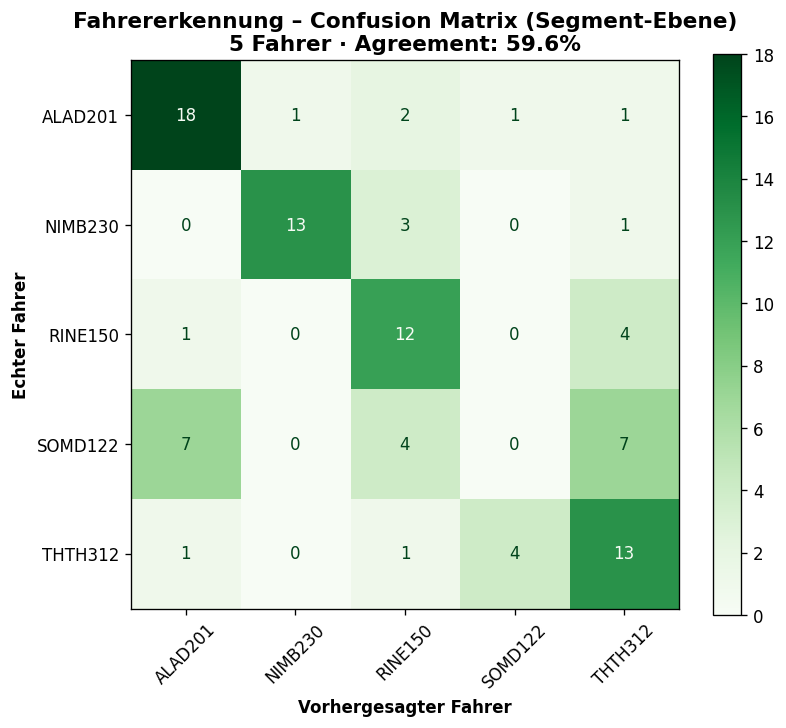

In [270]:
labels5_sorted = sorted(DRIVERS_5)
cm5 = confusion_matrix(test5['driver_id'], yp5, labels=labels5_sorted)
fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
ConfusionMatrixDisplay(cm5, display_labels=labels5_sorted).plot(
    ax=ax, cmap=plt.cm.Greens, xticks_rotation=45, colorbar=True)
ax.set_title(
    f'Fahrererkennung – Confusion Matrix (Segment-Ebene)\n'
    f'5 Fahrer · Agreement: {agr5:.1%}',
    fontweight='bold', fontsize=13)
ax.set_ylabel('Echter Fahrer', fontweight='bold')
ax.set_xlabel('Vorhergesagter Fahrer', fontweight='bold')
plt.tight_layout()
plt.show()


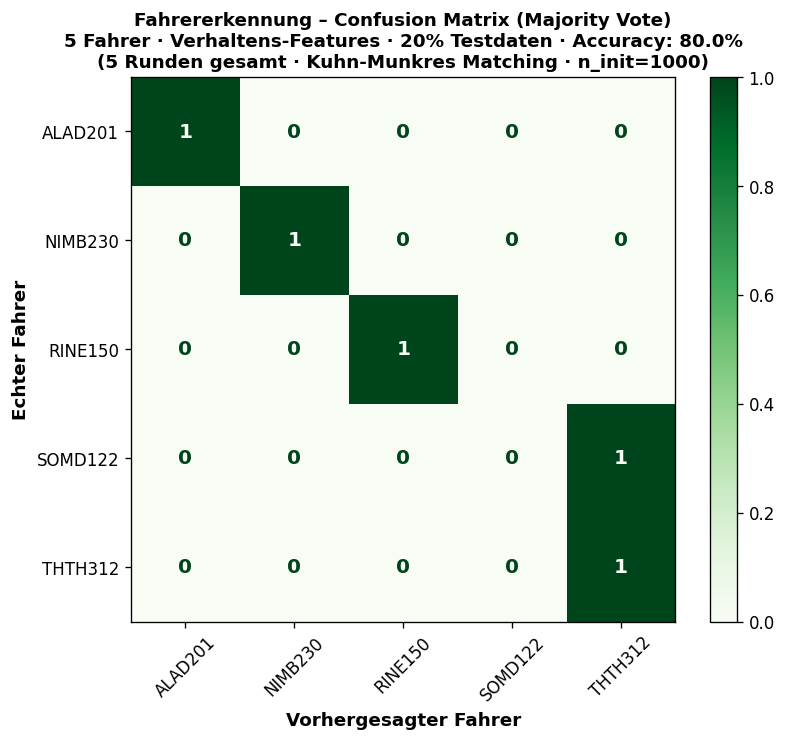

In [271]:
# Majority Vote CM: 5 Fahrer (je 12 Segmente pro Runde, per Fahrer)
mv_true5, mv_pred5 = [], []
for driver in labels5_sorted:
    mask = test5['driver_id'] == driver
    yt_d = test5.loc[mask, 'driver_id'].values
    yp_d = test5.loc[mask, 'Erkannter_Fahrer'].values
    for i in range(0, len(yt_d), 12):
        yt_b = yt_d[i:i+12]; yp_b = yp_d[i:i+12]
        if len(yt_b) < 12: continue  # nur vollstaendige Runden
        mv_true5.append(Counter(yt_b).most_common(1)[0][0])
        mv_pred5.append(Counter(yp_b).most_common(1)[0][0])

mv_acc5  = accuracy_score(mv_true5, mv_pred5)
n_rnd5   = len(mv_true5)
cm_mv5   = confusion_matrix(mv_true5, mv_pred5, labels=labels5_sorted)

fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
ConfusionMatrixDisplay(cm_mv5, display_labels=labels5_sorted).plot(
    ax=ax, cmap=plt.cm.Greens, xticks_rotation=45, colorbar=True)
for txt in ax.texts:
    txt.set_fontsize(12); txt.set_fontweight('bold')
ax.set_title(
    f'Fahrererkennung – Confusion Matrix (Majority Vote)\n'
    f'5 Fahrer · Verhaltens-Features · 20% Testdaten · Accuracy: {mv_acc5:.1%}\n'
    f'({n_rnd5} Runden gesamt · Kuhn-Munkres Matching · n_init=1000)',
    fontweight='bold', fontsize=11)
ax.set_ylabel('Echter Fahrer', fontweight='bold', fontsize=11)
ax.set_xlabel('Vorhergesagter Fahrer', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()


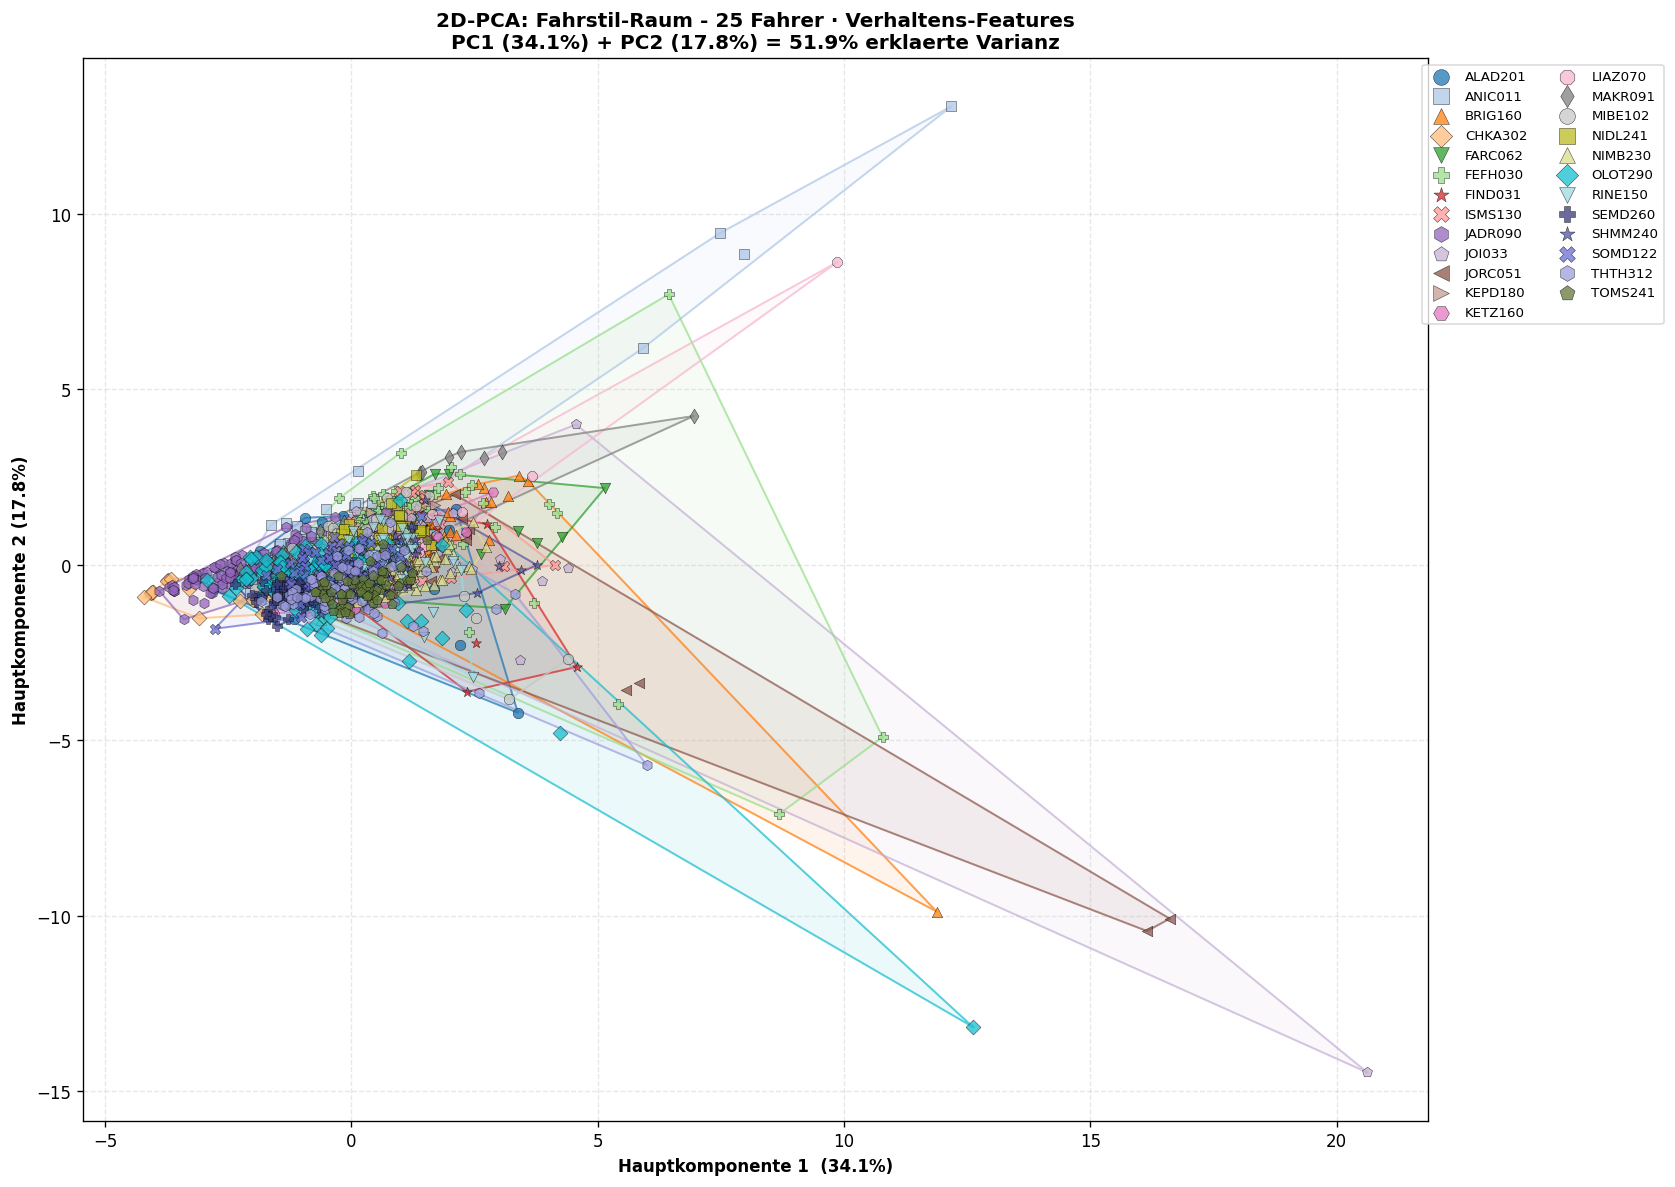

In [272]:
# 2D-PCA: 25 Fahrer (ohne per-Fahrer-Clipping fuer Visualisierung)
X_tr25_nc_vals = df_clean.loc[train25.index, FEATURE_COLS].values.astype(float)
mu_nc25  = X_tr25_nc_vals.mean(0)
sig_nc25 = X_tr25_nc_vals.std(0) + 1e-9
X_tr25_nc = (X_tr25_nc_vals - mu_nc25) / sig_nc25

_, S_25, Vt_25 = np.linalg.svd(X_tr25_nc, full_matrices=False)
var25 = (S_25[:2]**2) / (S_25**2).sum()
X_pca25      = X_tr25_nc @ Vt_25[:2].T
driver_ids25 = train25['driver_id'].values

# Nur gefuellte Marker (keine Linien-Marker wie x, +, 1, 2, |, _)
palette25   = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors[:5])
marker_list = ['o','s','^','D','v','P','*','X','h','p','<','>','H','8','d',
               'o','s','^','D','v','P','*','X','h','p']

fig, ax = plt.subplots(figsize=(14, 10), dpi=120)
for i, driver in enumerate(drivers_all):
    mask = driver_ids25 == driver
    pts  = X_pca25[mask]
    col  = palette25[i % len(palette25)]
    mrk  = marker_list[i % len(marker_list)]
    ax.scatter(pts[:,0], pts[:,1], color=col, marker=mrk, s=40, alpha=0.75,
               label=driver, edgecolors='k', linewidths=0.3, zorder=3)
    if len(pts) >= 3:
        try:
            hull = ConvexHull(pts)
            hp = pts[hull.vertices]; hp = np.vstack([hp, hp[0]])
            ax.fill(hp[:,0], hp[:,1], alpha=0.08, color=col, zorder=1)
            ax.plot(hp[:,0], hp[:,1], color=col, linewidth=1.2, alpha=0.7, zorder=2)
        except: pass

ax.set_title(
    f'2D-PCA: Fahrstil-Raum - 25 Fahrer · Verhaltens-Features\n'
    f'PC1 ({var25[0]*100:.1f}%) + PC2 ({var25[1]*100:.1f}%) = {var25[:2].sum()*100:.1f}% erklaerte Varianz',
    fontweight='bold', fontsize=12)
ax.set_xlabel(f'Hauptkomponente 1  ({var25[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'Hauptkomponente 2 ({var25[1]*100:.1f}%)', fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.18,1.0), ncol=2, fontsize=8,
          markerscale=1.5, frameon=True, facecolor='white', edgecolor='lightgray')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


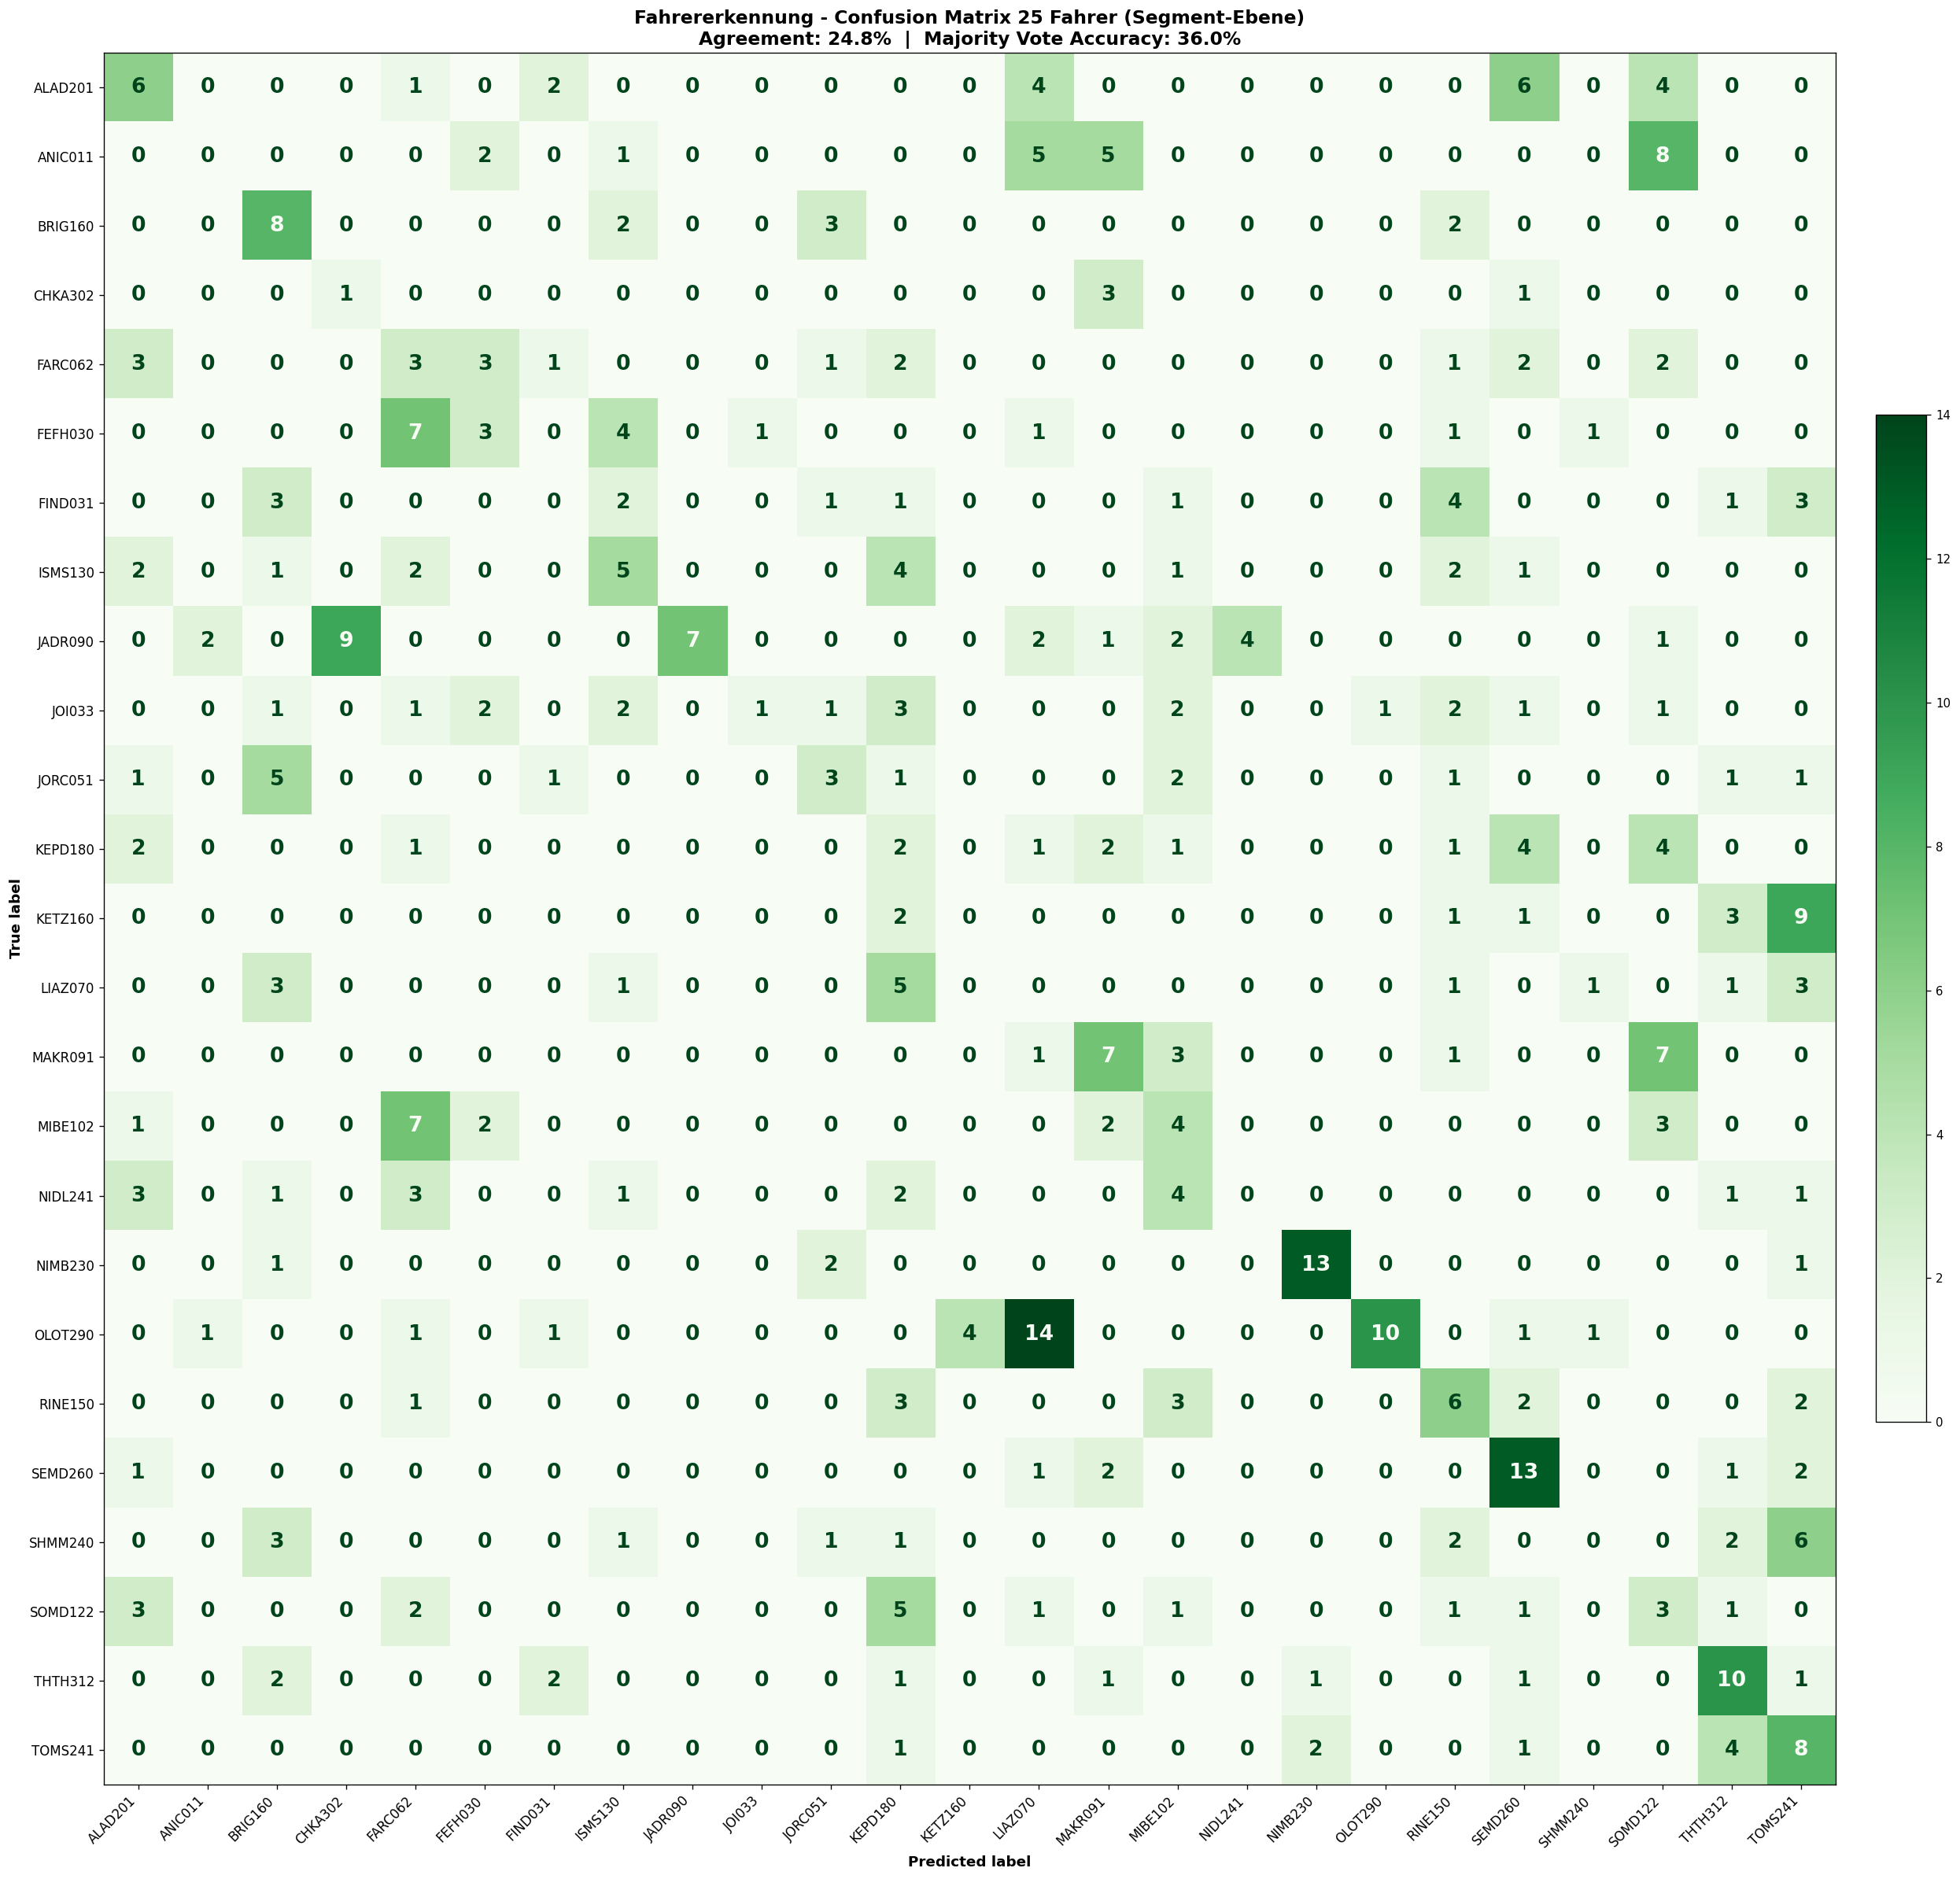

In [273]:
labels25_sorted = sorted(drivers_all)
cm25 = confusion_matrix(test25['driver_id'], yp25, labels=labels25_sorted)

# Majority Vote Accuracy aus CM
mv_acc25 = np.mean([cm25[i].argmax() == i for i in range(len(labels25_sorted))])

fig, ax = plt.subplots(figsize=(22, 20), dpi=120)
disp = ConfusionMatrixDisplay(cm25, display_labels=labels25_sorted)
disp.plot(ax=ax, cmap=plt.cm.Greens, xticks_rotation=45, colorbar=False)

# Zellwerte groesser
for text in ax.texts:
    text.set_fontsize(16)
    text.set_fontweight('bold')

# Tick-Labels lesbar
ax.tick_params(axis='both', labelsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)

# Kompakte Colorbar rechts
sm = plt.cm.ScalarMappable(cmap=plt.cm.Greens,
                            norm=plt.Normalize(vmin=0, vmax=cm25.max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.ax.tick_params(labelsize=9)

ax.set_title(
    f'Fahrererkennung - Confusion Matrix 25 Fahrer (Segment-Ebene)\n'
    f'Agreement: {agr25:.1%}  |  Majority Vote Accuracy: {mv_acc25:.1%}',
    fontweight='bold', fontsize=14)
ax.set_xlabel('Predicted label', fontsize=11, fontweight='bold')
ax.set_ylabel('True label', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


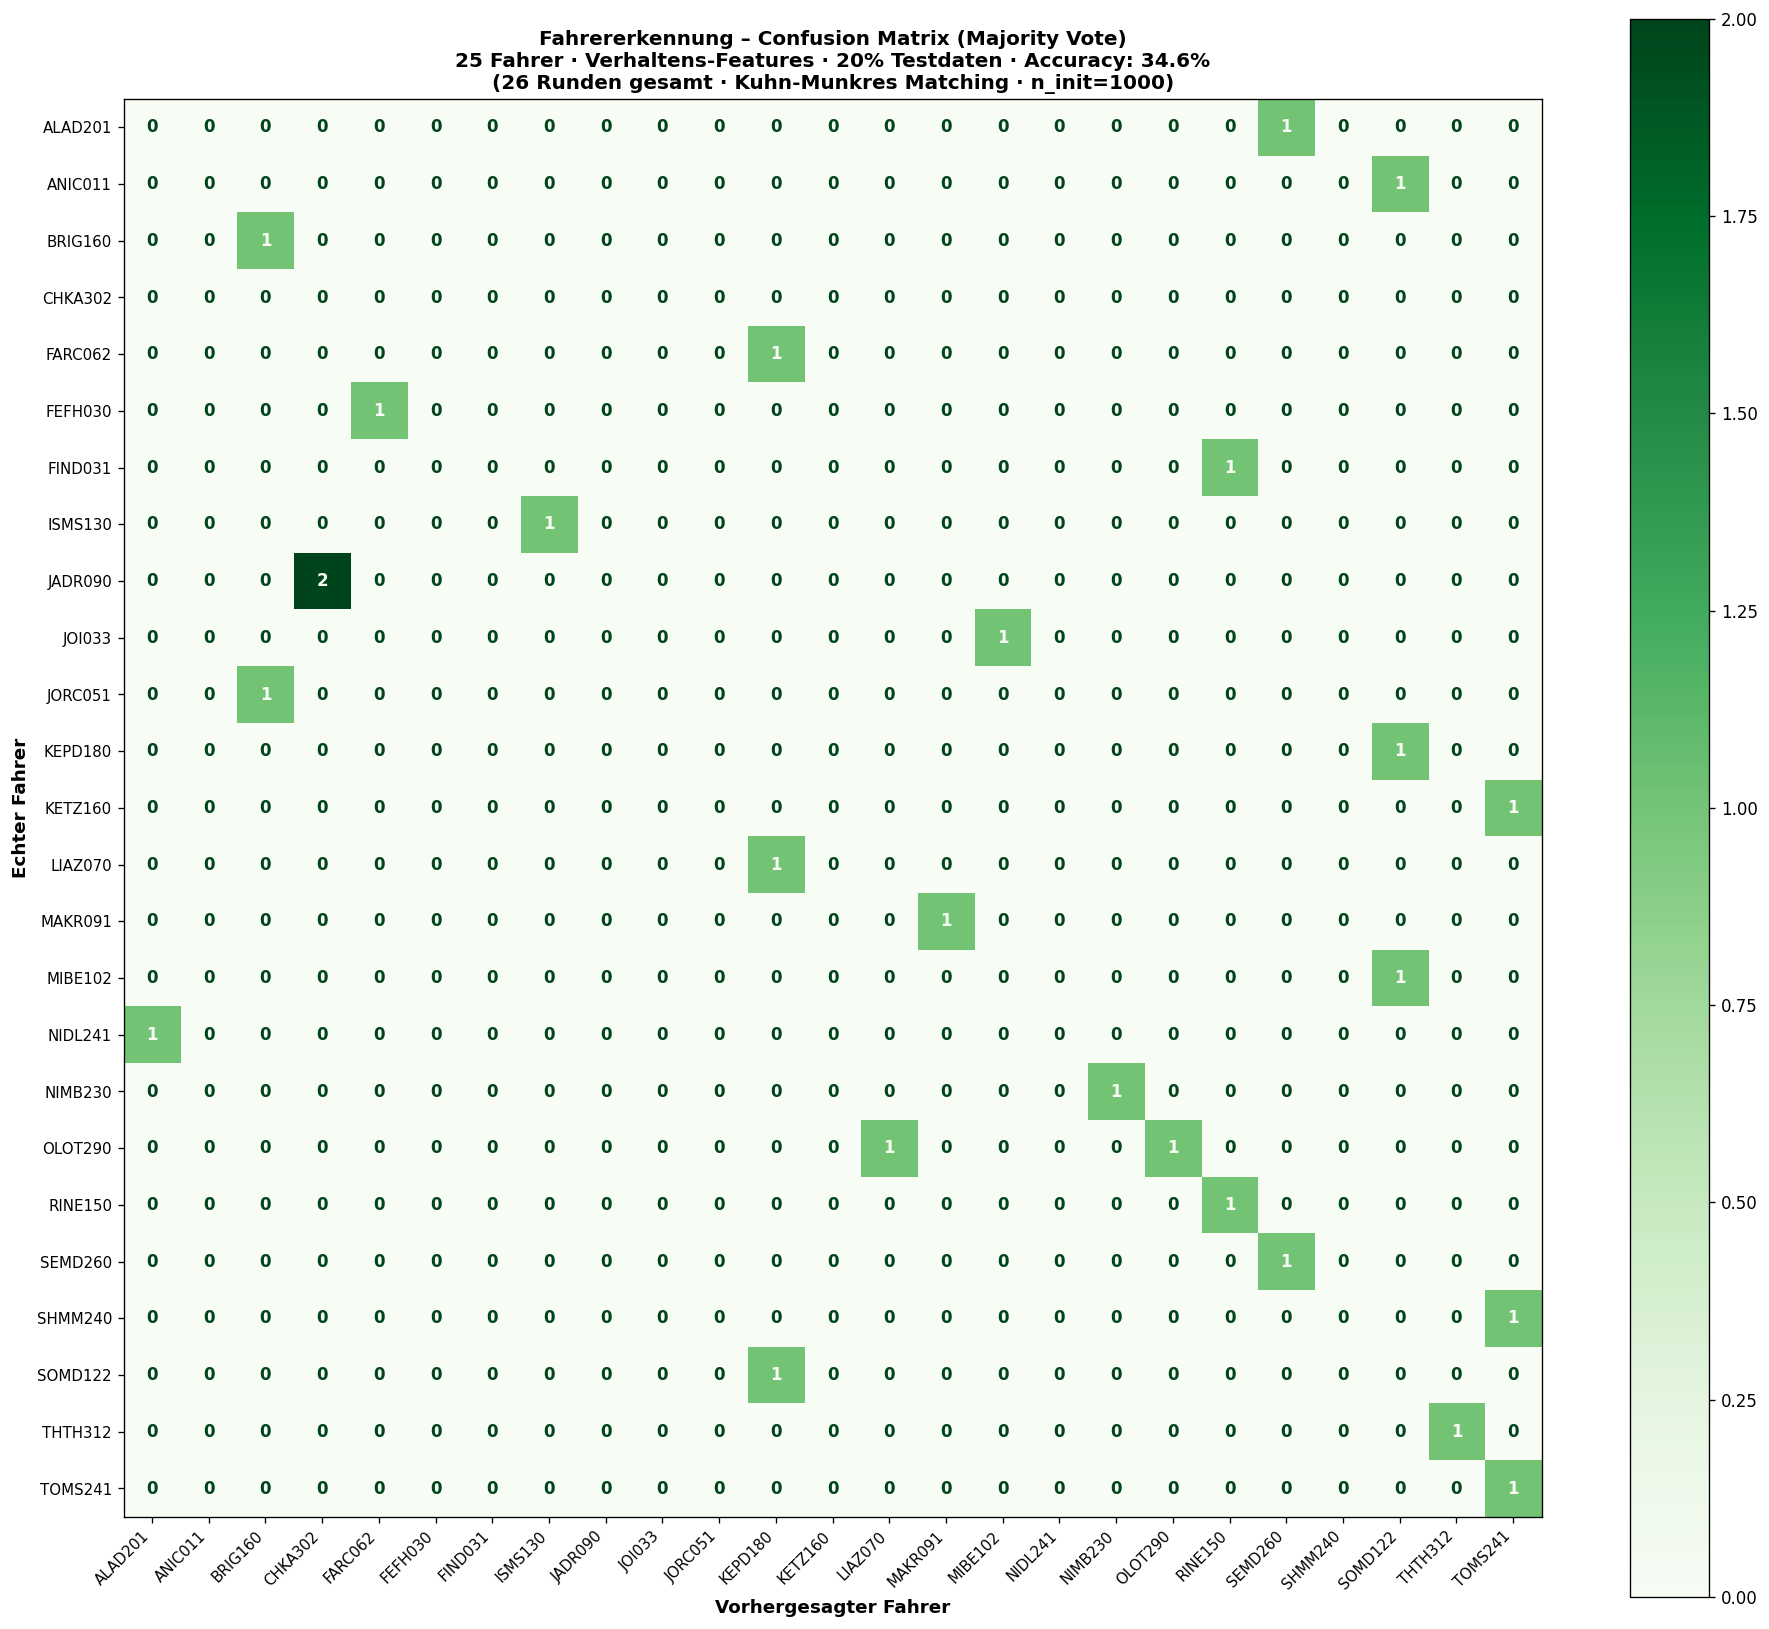

In [274]:
# Majority Vote CM: 25 Fahrer (je 12 Segmente pro Runde, per Fahrer)
mv_true25, mv_pred25 = [], []
for driver in labels25_sorted:
    mask = test25['driver_id'] == driver
    yt_d = test25.loc[mask, 'driver_id'].values
    yp_d = test25.loc[mask, 'Erkannter_Fahrer'].values
    for i in range(0, len(yt_d), 12):
        yt_b = yt_d[i:i+12]; yp_b = yp_d[i:i+12]
        if len(yt_b) < 12: continue  # nur vollstaendige Runden
        mv_true25.append(Counter(yt_b).most_common(1)[0][0])
        mv_pred25.append(Counter(yp_b).most_common(1)[0][0])

mv_acc25 = accuracy_score(mv_true25, mv_pred25)
n_rnd25  = len(mv_true25)
cm_mv25  = confusion_matrix(mv_true25, mv_pred25, labels=labels25_sorted)

fig, ax = plt.subplots(figsize=(16, 14), dpi=120)
disp = ConfusionMatrixDisplay(cm_mv25, display_labels=labels25_sorted)
disp.plot(ax=ax, cmap=plt.cm.Greens, xticks_rotation=45, colorbar=True)
for txt in ax.texts:
    txt.set_fontsize(10); txt.set_fontweight('bold')
ax.tick_params(axis='both', labelsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
ax.set_title(
    f'Fahrererkennung – Confusion Matrix (Majority Vote)\n'
    f'25 Fahrer · Verhaltens-Features · 20% Testdaten · Accuracy: {mv_acc25:.1%}\n'
    f'({n_rnd25} Runden gesamt · Kuhn-Munkres Matching · n_init=1000)',
    fontweight='bold', fontsize=12)
ax.set_ylabel('Echter Fahrer', fontweight='bold', fontsize=11)
ax.set_xlabel('Vorhergesagter Fahrer', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()


In [275]:
print(f"Accuracy   {mv_acc25:.1%}")
print(f"Agreement  {agr25:.1%}")
print(f"Confidence -")


Accuracy   34.6%
Agreement  24.8%
Confidence -


Skalierbarkeit berechnen (k=2..25)...
  k= 2: 100.0%
  k= 3: 66.7%
  k= 4: 100.0%
  k= 5: 80.0%
  k= 6: 83.3%
  k= 7: 71.4%
  k= 8: 71.4%
  k= 9: 62.5%
  k=10: 66.7%
  k=11: 60.0%
  k=12: 54.5%
  k=13: 53.8%
  k=14: 50.0%
  k=15: 53.3%
  k=16: 43.8%
  k=17: 35.3%
  k=18: 38.9%
  k=19: 26.3%
  k=20: 50.0%
  k=21: 28.6%
  k=22: 39.1%
  k=23: 45.8%
  k=24: 48.0%
  k=25: 34.6%
Lernkurve berechnen (fester test25, n_init=1000)...
  n_train=  91: MV=38.5%
  n_train= 145: MV=42.3%
  n_train= 218: MV=34.6%
  n_train= 309: MV=30.8%
  n_train= 400: MV=46.2%
  n_train= 509: MV=30.8%
  n_train= 637: MV=42.3%
  n_train= 764: MV=38.5%
  n_train= 910: MV=38.5%
  n_train=1055: MV=38.5%
  n_train=1183: MV=42.3%
  n_train=1365: MV=50.0%
  n_train=1820: MV=34.6%


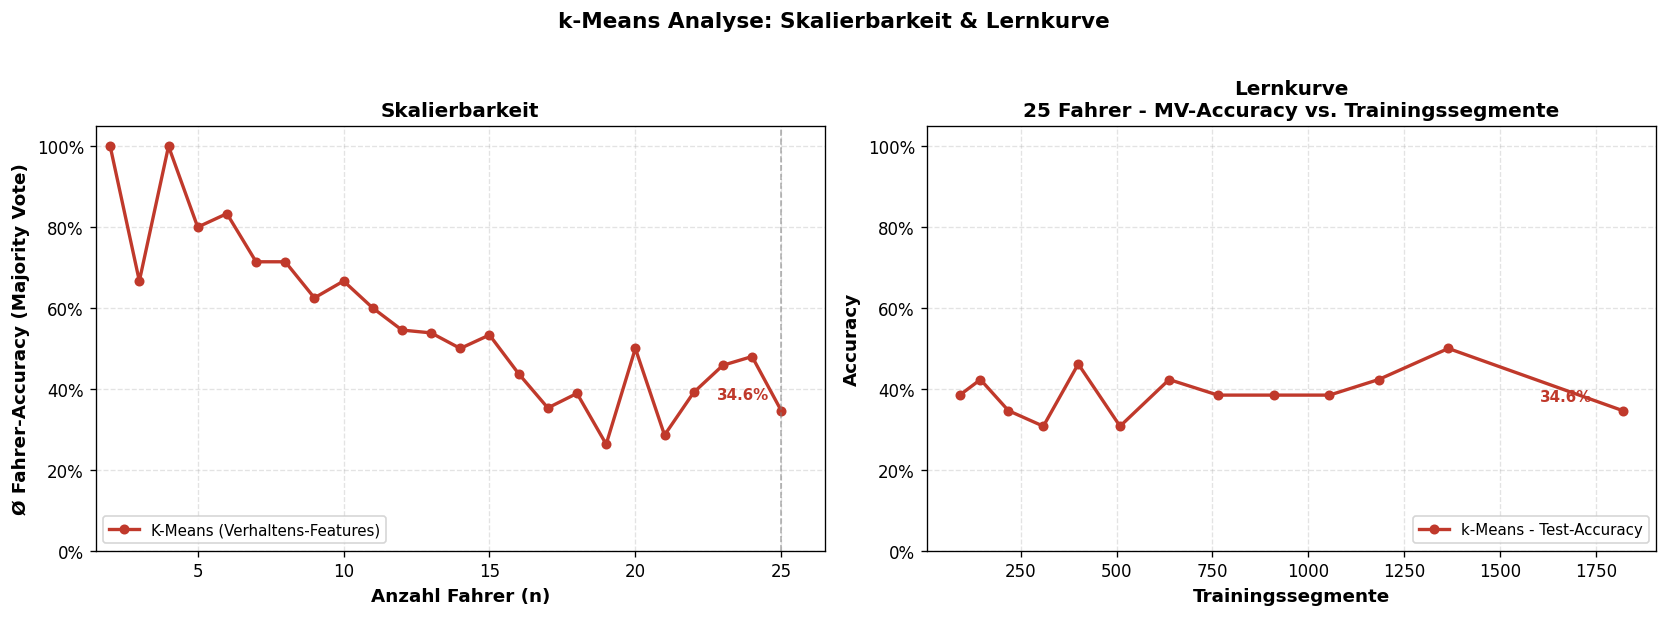

In [276]:
# ── Skalierbarkeit: k-Means MV-Accuracy fuer k=2..25 ──
remaining_drivers = [d for d in sorted(df_feat['driver_id'].unique()) if d not in DRIVERS_5]
driver_order = DRIVERS_5 + remaining_drivers

k_values = list(range(2, 26))
mv_sk    = []

print("Skalierbarkeit berechnen (k=2..25)...")
for k in k_values:
    drivers_k = driver_order[:k]
    df_k = df_feat[df_feat['driver_id'].isin(drivers_k)]
    tr_k, te_k = train_test_split(df_k, test_size=0.2,
                                   random_state=RANDOM_SEED, stratify=df_k['driver_id'])
    sc_k = StandardScaler()
    X_tr_k = sc_k.fit_transform(tr_k[FEATURE_COLS])
    X_te_k = sc_k.transform(te_k[FEATURE_COLS])
    lbl_k, ctr_k = kmeans(X_tr_k, k, n_init=200, seed=RANDOM_SEED)
    d2i_k = {d: i for i, d in enumerate(drivers_k)}
    cont_k = np.zeros((k, k), dtype=int)
    for cl, dr in zip(lbl_k, tr_k['driver_id']):
        cont_k[cl, d2i_k[dr]] += 1
    map_k = hungarian_mapping(cont_k)
    c2d_k = {cl: drivers_k[di] for cl, di in map_k.items()}
    Xsq = (X_te_k**2).sum(1); Csq = (ctr_k**2).sum(1)
    tl_k  = (Xsq[:,None] - 2*(X_te_k@ctr_k.T) + Csq[None,:]).argmin(1)
    y_true_k = te_k['driver_id'].values
    y_pred_k = np.array([c2d_k.get(l,'?') for l in tl_k])
    mv_t, mv_p = [], []
    for d in drivers_k:
        mask = y_true_k == d
        yt_d = y_true_k[mask]; yp_d = y_pred_k[mask]
        for i in range(0, len(yt_d), 12):
            if len(yt_d[i:i+12]) < 12: continue
            mv_t.append(Counter(yt_d[i:i+12]).most_common(1)[0][0])
            mv_p.append(Counter(yp_d[i:i+12]).most_common(1)[0][0])
    mv_sk.append(accuracy_score(mv_t, mv_p) if mv_t else 0.0)
    print(f"  k={k:2d}: {mv_sk[-1]:.1%}")

# ── Lernkurve: fester Test-Split (test25), variierender Trainingsanteil ──
# Subsets von train25 - immer gleicher Test -> MV-Runden bleiben konstant
train_fracs = [0.05, 0.08, 0.12, 0.17, 0.22, 0.28, 0.35, 0.42, 0.50, 0.58, 0.65, 0.75, 1.0]
lc_n_train  = []
lc_mv_km    = []
print("Lernkurve berechnen (fester test25, n_init=1000)...")
for frac in train_fracs:
    if frac >= 1.0:
        tr_sub = train25
    else:
        tr_sub, _ = train_test_split(train25, train_size=frac,
                                      random_state=RANDOM_SEED, stratify=train25['driver_id'])
    sc_sub = StandardScaler()
    X_tr_sub = sc_sub.fit_transform(tr_sub[FEATURE_COLS])
    X_te_sub = sc_sub.transform(test25[FEATURE_COLS])
    lc_n_train.append(len(tr_sub))
    lbl_sub, ctr_sub = kmeans(X_tr_sub, k25, n_init=1000, seed=RANDOM_SEED)
    d2i_sub = {d: i for i, d in enumerate(drivers_all)}
    cont_sub = np.zeros((k25, k25), dtype=int)
    for cl, dr in zip(lbl_sub, tr_sub['driver_id']):
        cont_sub[cl, d2i_sub[dr]] += 1
    map_sub = hungarian_mapping(cont_sub)
    c2d_sub = {cl: drivers_all[di] for cl, di in map_sub.items()}
    Xsq = (X_te_sub**2).sum(1); Csq = (ctr_sub**2).sum(1)
    tl_sub = (Xsq[:,None] - 2*(X_te_sub@ctr_sub.T) + Csq[None,:]).argmin(1)
    y_true_sub = test25['driver_id'].values
    y_pred_sub = np.array([c2d_sub.get(l,'?') for l in tl_sub])
    mv_t, mv_p = [], []
    for d in drivers_all:
        mask = y_true_sub == d
        yt_d = y_true_sub[mask]; yp_d = y_pred_sub[mask]
        for i in range(0, len(yt_d), 12):
            if len(yt_d[i:i+12]) < 12: continue
            mv_t.append(Counter(yt_d[i:i+12]).most_common(1)[0][0])
            mv_p.append(Counter(yp_d[i:i+12]).most_common(1)[0][0])
    lc_mv_km.append(accuracy_score(mv_t, mv_p) if mv_t else 0.0)
    print(f"  n_train={lc_n_train[-1]:4d}: MV={lc_mv_km[-1]:.1%}")

# ── Plots ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

ax1.plot(k_values, [v*100 for v in mv_sk], 'o-', color='#c0392b',
         linewidth=2, markersize=5, label='K-Means (Verhaltens-Features)')
ax1.axvline(x=25, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax1.annotate(f"{mv_sk[-1]:.1%}", xy=(25, mv_sk[-1]*100),
             xytext=(22.8, mv_sk[-1]*100+3), fontsize=9, color='#c0392b', fontweight='bold')
ax1.set_xlim(1.5, 26.5); ax1.set_ylim(0, 105)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0f}%'))
ax1.set_xlabel('Anzahl Fahrer (n)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Ø Fahrer-Accuracy (Majority Vote)', fontweight='bold', fontsize=11)
ax1.set_title('Skalierbarkeit', fontweight='bold', fontsize=12)
ax1.legend(fontsize=9); ax1.grid(True, linestyle='--', alpha=0.35)

ax2.plot(lc_n_train, [v*100 for v in lc_mv_km], 'o-', color='#c0392b',
         linewidth=2, markersize=5, label='k-Means - Test-Accuracy')
ax2.annotate(f"{lc_mv_km[-1]:.1%}", xy=(lc_n_train[-1], lc_mv_km[-1]*100),
             xytext=(-50, 6), textcoords='offset points',
             fontsize=9, color='#c0392b', fontweight='bold')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0f}%'))
ax2.set_xlabel('Trainingssegmente', fontweight='bold', fontsize=11)
ax2.set_ylabel('Accuracy', fontweight='bold', fontsize=11)
ax2.set_title('Lernkurve\n25 Fahrer - MV-Accuracy vs. Trainingssegmente', fontweight='bold', fontsize=12)
ax2.legend(fontsize=9, loc='lower right'); ax2.grid(True, linestyle='--', alpha=0.35)

plt.suptitle('k-Means Analyse: Skalierbarkeit & Lernkurve', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
